# Working with complicated dataset

Your name: Thang Cao

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [12]:
import pandas as pd
import urllib.request
from io import StringIO

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

# ---- read all lines ----
with urllib.request.urlopen(url) as resp:
    lines = [line.decode("utf-8").rstrip("\n") for line in resp]

fields_line = next(l for l in lines if "Fields:" in l)

first_q = fields_line.find('"')
second_q = fields_line.find('"', first_q + 1)
inside = fields_line[first_q + 1 : second_q]          # -> # Fields: ...
fields_part = inside.split("Fields:", 1)[1].strip()

# Column names are separated by ", " in that fields list
columns = [c.strip() for c in fields_part.split(", ")]

data_lines = [
    l for l in lines
    if not l.lstrip().startswith("#") and not l.lstrip().startswith('"#') and l.strip() != ""
]

df = pd.read_csv(
    StringIO("\n".join(data_lines)),
    header=None,
    names=columns,
    usecols=list(range(len(columns))),   # drops the extra empty column from trailing comma
    engine="python"
)

# Drop the first column and set the index
df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")

# Ensure publications is the last column
df = df[[c for c in df.columns if c != "publications"] + ["publications"]]

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [14]:
### Your code here . . .
# Convert publications to numeric (turn '-' into NaN)
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")

# Calculate average
df["publications"].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [16]:
# Clean bonds column first
df["bonds"] = (
    df["bonds"]
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")

# Now filter
df[df["bonds"] > 15000].index.tolist()

['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

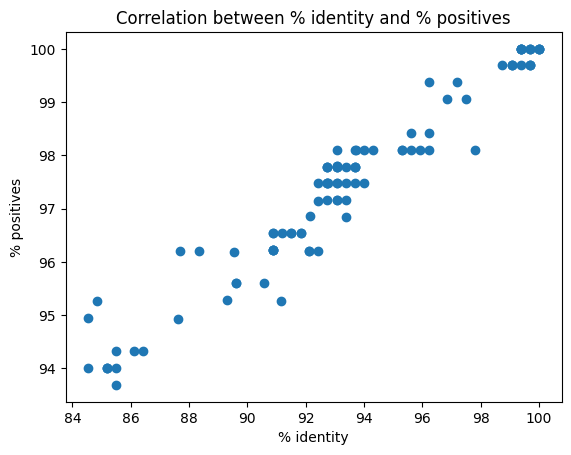

In [17]:
### Your code here . . .
import matplotlib.pyplot as plt
import pandas as pd

df["% identity"] = pd.to_numeric(df["% identity"], errors="coerce")
df["% positives"] = pd.to_numeric(df["% positives"], errors="coerce")

# Create scatter plot
plt.figure()
plt.scatter(df["% identity"], df["% positives"])
plt.xlabel("% identity")
plt.ylabel("% positives")
plt.title("Correlation between % identity and % positives")
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [18]:
### Your code here . . .
# Load protein source file
protein_df = pd.read_csv(
    "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv",
    index_col=0   # ignore the first column (0,2,12,...)
)

# Merge using subject acc.ver (index) = Protein
df = df.merge(
    protein_df[["Protein", "Source"]],
    left_index=True,
    right_on="Protein",
    how="left"
)

# Rename Source column to "Protein source"
df = df.rename(columns={"Source": "Protein source"})

df = df.set_index("Protein")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
Protein,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
